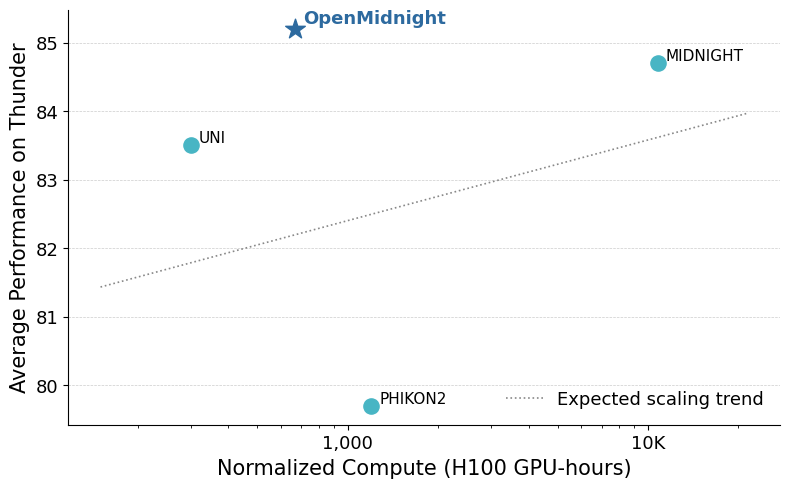

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ============================================================
# DATA — edit as needed
# Format: 'Model Name': (H100_gpu_hours, avg_performance)
# GPU hours from blog figure — update with confirmed values
# ============================================================
models = {
    'MIDNIGHT': (10_752, 84.7),
    'PHIKON2': (1_200, 79.7),
    'UNI': (300, 83.5),
}

our_model = {
    'OpenMidnight': (667, 85.2),
}

# ============================================================
# Colors
# ============================================================
COLOR_OURS   = '#2D6A9F'  # cobalt
COLOR_OTHERS = '#48B5C4'  # cyan

## ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

# --- Other models ---
for name, (gpu_hrs, perf) in models.items():
    ax.scatter(gpu_hrs, perf, color=COLOR_OTHERS, s=120, zorder=3)  # was 80
    ax.annotate(name, (gpu_hrs, perf), textcoords='offset points',
                xytext=(6, 2), fontsize=11, color='black')  # was 8

# --- Our model ---
for name, (gpu_hrs, perf) in our_model.items():
    ax.scatter(gpu_hrs, perf, color=COLOR_OURS, s=220, zorder=5, marker='*')  # was 140
    ax.annotate(name, (gpu_hrs, perf), textcoords='offset points',
                xytext=(6, 4), fontsize=13, fontweight='bold', color=COLOR_OURS)  # was 9.5

# --- Expectation line (log-linear fit) ---
all_x = np.array([v[0] for v in models.values()])
all_y = np.array([v[1] for v in models.values()])
log_x = np.log10(all_x)
coeffs = np.polyfit(log_x, all_y, 1)
x_line = np.logspace(np.log10(min(all_x)) - 0.3,
                      np.log10(max(all_x)) + 0.3, 200)
y_line = coeffs[0] * np.log10(x_line) + coeffs[1]
ax.plot(x_line, y_line, linestyle=':', linewidth=1.2,
        color='#888888', zorder=1, label='Expected scaling trend')

# --- Axes & style ---
ax.set_xscale('log')
ax.set_xlabel('Normalized Compute (H100 GPU-hours)', fontsize=15)  # was 12
ax.set_ylabel('Average Performance on Thunder', fontsize=15)  # was 12, expanded wording
ax.tick_params(axis='both', labelsize=13)  # was 10

ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x):,}' if x < 10_000 else f'{int(x/1000)}K'
))

ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='gray')
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(fontsize=13, frameon=False, loc='lower right')  # was 10

plt.tight_layout()
plt.savefig('perf_vs_compute.png', dpi=300, bbox_inches='tight')
plt.show()